In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_train = pd.read_csv("Google_Stock_Price_Train.csv")
dataset_train.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [3]:
training_set = dataset_train.iloc[:, 1:2].values

In [4]:
training_set

array([[325.25],
       [331.27],
       [329.83],
       ...,
       [793.7 ],
       [783.33],
       [782.75]])

In [5]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler(feature_range = (0,1))
training_set_scale = mms.fit_transform(training_set)

In [17]:
x_train = []
y_train = []

for i in range(60, 1258):
    x_train.append(training_set_scale[i-60:i,0])
    y_train.append(training_set_scale[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))

In [18]:
from keras.models import Sequential
from keras.layers import Dense,LSTM,Dropout

2026-02-03 15:59:30.742110: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-03 15:59:30.898741: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-03 15:59:30.900574: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-03 15:59:32.364365: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [19]:
regressor = Sequential()

In [23]:
regressor.add(LSTM(units = 50, return_sequences = True, input_shape = (x_train.shape[1],1)))
regressor.add(Dropout(0.2))

In [24]:
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

In [25]:
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

In [26]:
regressor.add(LSTM(units = 50))
regressor.add(Dropout (0.2))

In [27]:
regressor.add(Dense(units = 1))

In [31]:
regressor.compile(optimizer = "adam", loss = "mean_squared_error")

In [32]:
regressor.fit(x_train, y_train, epochs = 100, batch_size = 32)

Epoch 1/100
38/38 [==============================] - 13s 91ms/step - loss: 0.0511
Epoch 2/100
38/38 [==============================] - 3s 88ms/step - loss: 0.0081
Epoch 3/100
38/38 [==============================] - 3s 87ms/step - loss: 0.0086
Epoch 4/100
38/38 [==============================] - 3s 88ms/step - loss: 0.0067
Epoch 5/100
38/38 [==============================] - 3s 90ms/step - loss: 0.0066
Epoch 6/100
38/38 [==============================] - 3s 92ms/step - loss: 0.0055
Epoch 7/100
38/38 [==============================] - 3s 87ms/step - loss: 0.0061
Epoch 8/100
38/38 [==============================] - 3s 87ms/step - loss: 0.0051
Epoch 9/100
38/38 [==============================] - 3s 89ms/step - loss: 0.0055
Epoch 10/100
38/38 [==============================] - 3s 88ms/step - loss: 0.0055
Epoch 11/100
38/38 [==============================] - 3s 91ms/step - loss: 0.0050
Epoch 12/100
38/38 [==============================] - 3s 91ms/step - loss: 0.0046
Epoch 13/100
38/38 [====

In [33]:
dataset_test = pd.read_csv("Google_Stock_Price_Test.csv")
dataset_test.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2017,778.81,789.63,775.80,786.14,"1,657,300"
1,1/4/2017,788.36,791.34,783.16,786.90,"1,073,000"
2,1/5/2017,786.08,794.48,785.02,794.02,"1,335,200"
3,1/6/2017,795.26,807.90,792.20,806.15,"1,640,200"
4,1/9/2017,806.40,809.97,802.83,806.65,"1,272,400"


In [34]:
testing_set = dataset_test.iloc[:, 1:2].values

In [39]:
dataset_total = pd.concat((dataset_train["Open"], dataset_test["Open"]), axis =0)
inputs = dataset_total[len(dataset_total) -len(dataset_test) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = mms.transform(inputs)

x_test = []

for i in range(60,80):
    x_test.append(inputs[i-60:i,0])
    
x_test = np.array(x_test)
x_test = np.reshape(x_test,(x_test.shape[0],x_test.shape[1],1))


predicted_stock_price = regressor.predict(x_test)
predicted_stock_price = mms.inverse_transform(predict_stock_price)

1/1 [==============================] - 0s 80ms/step


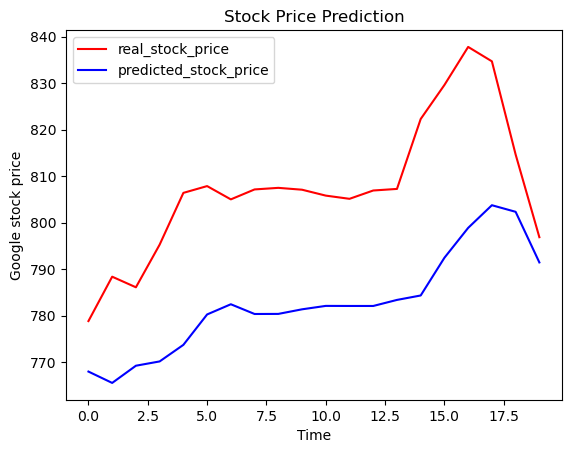

In [40]:
plt.plot(testing_set, color = 'r',label = "real_stock_price")
plt.plot(predict_stock_price, color = 'b', label = "predicted_stock_price")
plt.title("Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Google stock price")
plt.legend()
plt.show()

In [42]:
#mms.predict([1/3/2012,325.25,332.83,324.97,663.59])